# Control flow

## Computing integrals using trapezoidal rule

The value of the integral can be estimated using trapezoidal sum for the underlying area

$$\int_a^b f(x) dx$$

Dividing the interval $[a, b]$ into $n$ equal sized slices, and using the simple trapezoid area formula, it boils down to

$$
       \int_a^b f(x)\,dx  \approx  \frac{b-a}{n} \left(\frac{1}{2}(f(a) +
          f(b)) + \sum_{k=1}^{n-1} f \left( a+k \frac{b-a}{n} \right)\right)
$$

To derive it, consider the following figure:

![Trapezoid](Images/trapezoid.png)

The result can be iteratively refined adding more intervals

$$I_1 = \left[\frac{1}{2}(f(a)+f(b))\right](b-a)/1$$

$$I_2 = \left[\frac{1}{2}(f(a)+f(b))+f(c_1)\right](b-a)/2$$

$$I_3 = \left[\frac{1}{2}(f(a)+f(b))+f(c_1)+f(c_2)\right](b-a)/3$$

$$I_n = \left[ \frac{1}{2}(f(a)+f(b)) + \dots + f(c_{n-1}) \right] (b-a) / n = Acc * dx$$

In [2]:
# dear students, don't mind this cell. Just execute it. It's code to plot our integral estimation with n intervals.
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

def my_plot_function(a, b, steps, f=lambda x: x*x, max_steps=10000):
    if steps > 1024: print("Too dense! Skip plotting ..."); return
    x = np.linspace(a,b,max_steps)
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(x, f(x), '-', lw=3, color='blue')
    x_c = np.linspace(a,b,steps)
    y_c = f(x_c)
    dx = (b-a)/steps
    for i_s in range(steps):
        xx = a+i_s*dx
        xxp1 = a+(i_s+1)*dx
        poly = Polygon([(xx,0), (xxp1,0), (xxp1, f(xxp1)), (xx,f(xx))], facecolor='0.9', edgecolor='0.5')
        ax.add_patch(poly)

## Using iterative approach

We can estimate the integral value choosing a certain number of intervals. But how many intervals are good enough?

The "good enough" depends on the precision (or tolerance) we want on the evaluation.

Once we choose an order of magnitude we want our evaluation to be bound, we can start computing the integral using K intervals.

After this first initial evaluation, we double the intervals and compute a new evaluation. If the absolute difference of the previous and current estimate is below our tolerance, we should be satisfied with this latter estimate. Otherwise, we should keep increasing the number of intervals until we reach the desired tolerance. 

This approach is an "iterative" algorithm and can be expressed using the "while" control statement in python.

### Estimate the integral of $f(x) = x^2$ in the interval $[-1, 2]$

Current estimate using  1  intervals with dx = 3.0  is  7.5
Current estimate using  2  intervals with dx = 1.5  is  4.125
Current estimate using  4  intervals with dx = 0.75  is  3.28125
Current estimate using  8  intervals with dx = 0.375  is  3.0703125
Current estimate using  16  intervals with dx = 0.1875  is  3.017578125
Current estimate using  32  intervals with dx = 0.09375  is  3.00439453125
Integral estimate:  3.0010986328125


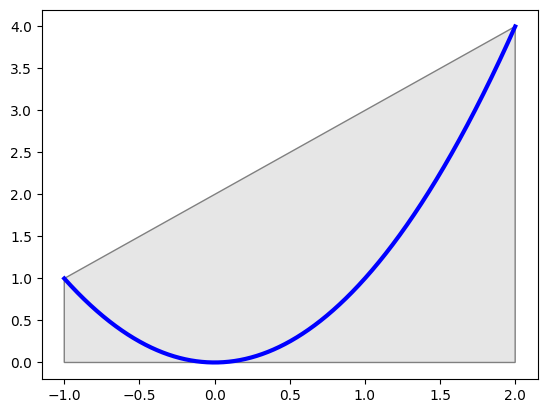

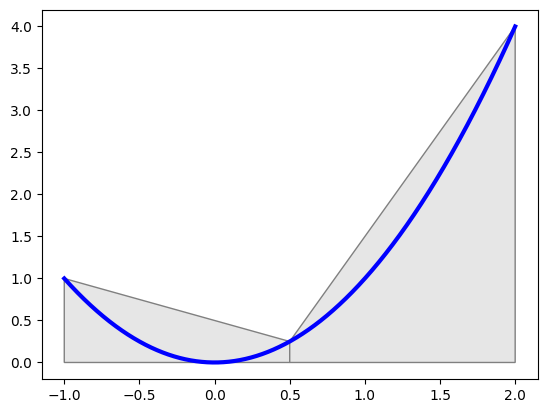

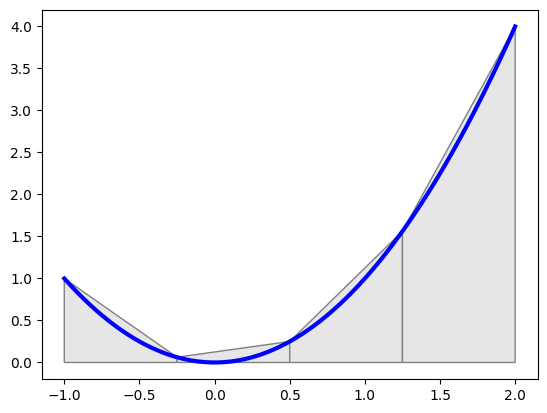

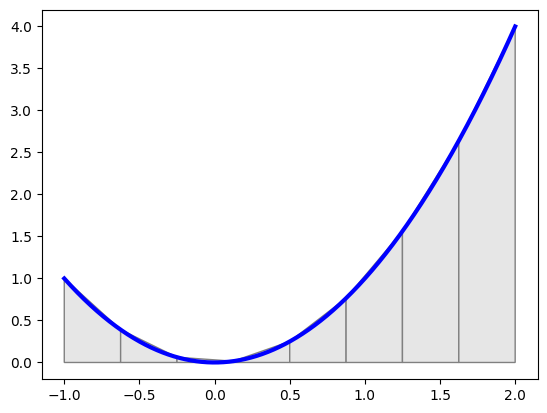

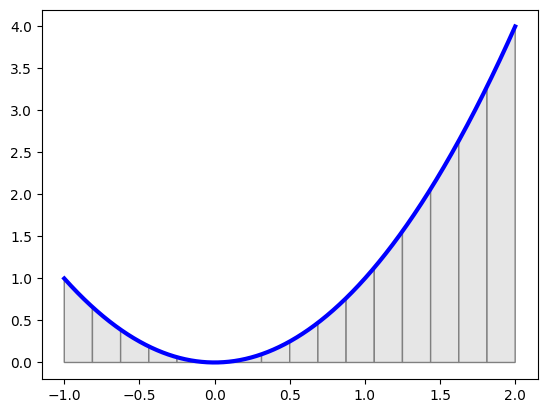

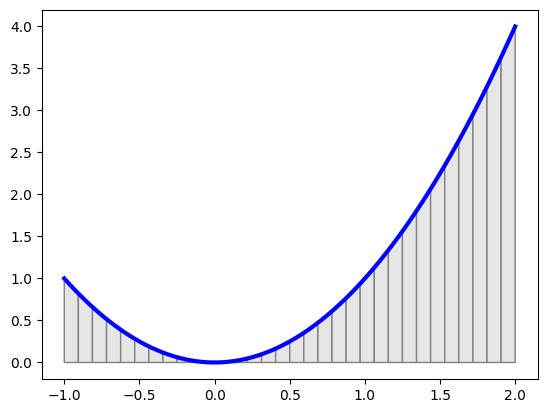

In [3]:
# Input interval, tolerance, max number of iteration steps, steps counter
a = -1.0 ; b = 2.0 ; tol = 0.01; maxsteps = 2**23; steps = 1
intervals = 1 # starting number of intervals

# Initial estimate
x=a  ; fa = x**2 ; x=b  ; fb = x**2
acc = (fa + fb) * 0.5 # accumulation variable
dx = (b - a) / intervals
estimate = acc * dx
prev_estimate = estimate + 2*tol # initial value to ensure first evaluation is executed

while abs(estimate - prev_estimate) > tol:
    my_plot_function(a=a, b=b, steps=intervals)
    print("Current estimate using ", intervals, " intervals with dx =", dx, " is ", estimate)
    prev_estimate = estimate
    intervals *= 2; dx *= 0.5 # dx will keep halving, intervals doubling
    for i in range(1, intervals + 1, 2):   # only contributions from new points
        x = a+i*dx ; acc += x**2
    estimate = acc * dx
    steps = steps + 1
    if steps > maxsteps: break

    
print("Integral estimate: ", estimate)

## while

```python
while <condition>:
    <statements>
```
* With the while loop we can execute a set of statements as long as a condition is True

In [4]:
i = 1
while i < 6:
    print(i**3)
    i += 1

1
8
27
64
125


## while

```python
while <condition>:
    <statements>
```
* With the `while` loop we can execute a set of statements as long as a condition is True
* The `break` statement stops the loop even if the while condition is True:
   * best practice: never let a loop possibly go on forever

In [5]:
i = 1
while i < 6:
    print(i**3)
    if i == 3:
        break
    i += 1

1
8
27


## while

```python
while <condition>:
    <statements>
```
* With the while loop we can execute a set of statements as long as a condition is True
* The `break` statement stops the loop even if the while condition is True:
   * best practice: never let a loop possibly go on forever
* The `continue` statement stops the current iteration, but continues with the next

In [6]:
i = 1
while i < 10:
    i += 1
    if i%2 == 0:
        continue
    print("i =", i, "; i**3 =",i**3)

i = 3 ; i**3 = 27
i = 5 ; i**3 = 125
i = 7 ; i**3 = 343
i = 9 ; i**3 = 729


## After the `while`
* A common usage is `break` corresponding to an error or warning condition, e.g. the integral did not reach convergence
   * in that case after the while ends, it would be interesting to know if convergence was reached or not
   * using booleans might achieve the goal but Python has a more elegant way
   * `else` clause in while means that the loop ended without executing `break` statements inside

### `while: ... else`

In [7]:
# Input interval, tolerance, max number of iteration steps, steps counter
a = -1.0 ; b = 2.0 ; tol = 1.e-5; maxsteps = 2**23; steps = 1
intervals = 1 # starting number of intervals

# Initial estimate
x=a  ; fa = x**2 ; x=b  ; fb = x**2
acc = (fa + fb) * 0.5 # accumulation variable
dx = (b - a) / intervals
estimate = acc * dx
prev_estimate = estimate + 2*tol # initial value to ensure first evaluation is executed

while abs(estimate - prev_estimate) > tol:
    print("Current estimate using ", intervals, " intervals with dx =", dx, " is ", estimate)
    prev_estimate = estimate
    intervals *= 2; dx *= 0.5 # dx will keep halfling, intervals doubling
    for i in range(1, intervals + 1, 2):   # only contributions from new points
        x = a+i*dx ; acc += x**2
    estimate = acc * dx
    steps = steps + 1
    if steps > maxsteps: 
        print("warning! convergence not reached after maxsteps=",maxsteps)
        break
else:
    print("convergence reached after ", steps, " iterations")

print("Integral estimate: ", estimate)

Current estimate using  1  intervals with dx = 3.0  is  7.5
Current estimate using  2  intervals with dx = 1.5  is  4.125
Current estimate using  4  intervals with dx = 0.75  is  3.28125
Current estimate using  8  intervals with dx = 0.375  is  3.0703125
Current estimate using  16  intervals with dx = 0.1875  is  3.017578125
Current estimate using  32  intervals with dx = 0.09375  is  3.00439453125
Current estimate using  64  intervals with dx = 0.046875  is  3.0010986328125
Current estimate using  128  intervals with dx = 0.0234375  is  3.000274658203125
Current estimate using  256  intervals with dx = 0.01171875  is  3.0000686645507812
Current estimate using  512  intervals with dx = 0.005859375  is  3.0000171661376953
Current estimate using  1024  intervals with dx = 0.0029296875  is  3.000004291534424
convergence reached after  12  iterations
Integral estimate:  3.000001072883606


## `for` and `range`
* `range(start, stop, step)`
   * start (Optional): integer number specifying at which position to start. Default is 0
   * stop (Required): integer number specifying at which position to end (excluded).
   * step (Optional): integer number specifying the incrementation. Default is 1    

In [8]:
for i in range(5):
    print(i, end=" ")
print("\n---------")
for i in range(3,8,2):
    print(i, end=" ")

0 1 2 3 4 
---------
3 5 7 

* Python `for` allows to loop over the range values (iterates over the items of any sequence)
   * statements to be repeated according to for must be properly indented
   * `for` can be indented
   * `break` and `continue` work here too
   * and `else` as well
   * is much more powerful than this (see more later)

## Exiting from nested loops
* Can you understand this?

In [9]:
for i in range(3):
    for j in range(3,8,2):
        print(i, j)
        if i+j > 6: 
            # break # try to comment out this break
            print("after nested break")
    else:
        print("continue")
        continue
    print("break")
    break

0 3
0 5
0 7
after nested break
continue
1 3
1 5
1 7
after nested break
continue
2 3
2 5
after nested break
2 7
after nested break
continue


## Hands-on 3.1

Approximate numerically:

$$l=\sqrt{30+\sqrt{30+\sqrt{30+\sqrt{30+\sqrt{30+\sqrt{30+...}}}}}}$$

$$a_0  = \sqrt{30}$$

$$a_1 = \sqrt{30+a_0}$$

$$a_2= \sqrt{30+a_1}$$

$$...$$

$$a_{n+1}= \sqrt{30+a_n}$$


## Hands-on 3.2
Find the number of addends required to have

$$-1^2+2^2-3^2+4^2-5^2+6^2-7^2+8^2...$$

equal to a positive number having digits 

$$aabb$$

# Rights & Credits

These slides are CINECA 2018 and are released under the Attribution-NonCommercial-NoDerivs (CC BY-NC-ND) Creative Commons license, version 3.0. 

Uses not allowed by the above license need explicit, written permission from the copyright owner.

For more information see:
http://creativecommons.org/licenses/by-nc-nd/3.0/

Slides and examples were authored by:
**Sergio Orlandini**, **Francesco Salvadore**